In [1]:
from ultralytics import YOLO
from matplotlib import pyplot as plt
from PIL import Image

In [2]:
# model = YOLO('yolov8x-seg.yaml')  i dont need it right now as this line builds the model from scratch, but i dont want that; ---> random weights;

# --> this yolo segmentation model is already pre-trained on COCO Dataset, and i am gonna use the transfer learning(custom training) on this model;
model = YOLO('yolov8m-seg.pt')

In [3]:

# ---> name of the folder where all results would be stored;
project = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\PanNuke_Results"


name = "50_epochs-"  # sub-directory for epoch specific training; this would create a folder-name <name> and if u rerun the training it it will create <name-2>

In [10]:
# training;

results = model.train(data=r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_YOLOv8x_Dataset\data.yaml",
                      project=project,
                      name=name,
                      epochs=50,
                      patience=20,  # ---> this is early stopping = means if validation stops improving then stop the training early, if set '0' --> run all epochs no matter what;
                      batch=-1,  # how many images processed at once, means how many images the yolov8x sees before updating weights; if set '-1' ---> yolo model will auto adjust the batch size by judging the GPU VRAM;
                      imgsz=640)

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.24  Python-3.11.0 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_YOLOv8x_Dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_

MemoryError: 

In [4]:
results = model.train(data=r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_YOLOv8x_Dataset\data.yaml",
                      project=project,
                      name=name,
                      epochs=50,
                      patience=20,  # ---> this is early stopping = means if validation stops improving then stop the training early, if set '0' --> run all epochs no matter what;
                      batch=4,  # how many images processed at once, means how many images the yolov8x sees before updating weights; if set '-1' ---> yolo model will auto adjust the batch size by judging the GPU VRAM;
                      imgsz=640)

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.24  Python-3.11.0 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_YOLOv8x_Dataset\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_d

In [8]:
# Training Done, Now INFERENCE....

model = YOLO(r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\PanNuke_Results\50_epochs-\weights\best.pt")

test_img = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_Dataset_Splitted\test\images\1-530.png"

import cv2

single_result = model(test_img)

img = single_result[0].plot(
    labels=False,
    conf=False,
    boxes=True, line_width=1
)
cv2.imwrite(r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\PanNuke_Results\Segmentation_Results\seg_1_result.png", img)


image 1/1 E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_Dataset_Splitted\test\images\1-530.png: 640x640 29 nucleuss, 55.5ms
Speed: 4.8ms preprocess, 55.5ms inference, 4.2ms postprocess per image at shape (1, 3, 640, 640)


True

In [10]:
import numpy as np

In [26]:
# used to compute area of polygon masks, converts contour --> geometric shape
from shapely.geometry import Polygon
r = single_result[0]  # YOLO returns a list, You take the first image result

# img_h, img_w = masks.shape[1], masks.shape[2]
# img_area = img_h * img_w
# print(img_h, img_w) # ---> this is showing 640x640 beacuse i used imagez in YOLOv8m training so YOLOv8m taking the 256x256(original size), internally converting it into 640x640 and doing the inference, and during saving the segmented img back into disk it is again going from 640x640 ---> 256x256 and saving, thatswhy masks.shape = 640x640, but this is wrong as per the physical properties of the img so we will not use this ;


areas = []  # raw areas
norm_areas = []  # normalized areas

# this r.orig_shape = uses true image size (256×256), not YOLOv8m internal(640x640)
img_h, img_w = r.orig_shape
img_area = img_h * img_w

polygons = r.masks.xy  # each nucleus → polygon (list of points)

nuclei_count = len(polygons)  # number of detected objects(nucleus)

for poly in polygons:  # looping through each nucleus;

    # each nucleus converted into geometrical objects; so now, nucleus = polygon;
    polygon = Polygon(poly)

    # RAW VALUES, area of single nucleus ----> measures how big is the nucleus ????
    area = polygon.area
    areas.append(area)

    # NORMALIZED VALUES, area of single nucleus ----> measures how big is the nucleus respect to the image ????
    norm_area = area / img_area
    norm_areas.append(norm_area)


total_area = sum(areas)  # total area of all nuclei combined;
avg_area = total_area / nuclei_count if nuclei_count > 0 else 0 # raw size of single nucleus;

avg_norm_area = sum(norm_areas) / nuclei_count if nuclei_count > 0 else 0 # average relative size of single nucleus; ----> 0.013054367730064057 = ~1.3%

density = nuclei_count / img_area  # how crowded nuclei are

# Output
print("Nuclei count:", nuclei_count)
print("Total area (pixels):", total_area)
print("Average area (pixels):", avg_area)
print("Average normalized area:", avg_norm_area)
print("Density:", density)

Nuclei count: 29
Total area (pixels): 24810.400263166863
Average area (pixels): 855.531043557478
Average normalized area: 0.013054367730064057
Density: 0.0004425048828125


In [31]:
# Now gonna do this for all of the test images : 
import os 
import random
import pandas as pd


TEST_DIR = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\PanNuke_Dataset_Splitted\test\images"
OUT_IMG_DIR = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\PanNuke_Results\Dump_Seg_Results"
OUT_CSV = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\PanNuke_Results\Dump_Seg_Results\nuclei_analysis.csv"



In [ ]:
data = []

# Loop through images
for img_name in os.listdir(TEST_DIR):
    if not img_name.endswith(".png"):
        continue

    img_path = os.path.join(TEST_DIR, img_name)

    # Run inference
    results = model.predict(img_path, conf=0.25, verbose=False)
    r = results[0]

    # Read original image
    img = cv2.imread(img_path)
    img_h, img_w = img.shape[:2]
    img_area = img_h * img_w

    # ----------- CASE: NO DETECTIONS -----------
    if r.masks is None or len(r.masks.xy) == 0:
        cv2.imwrite(os.path.join(OUT_IMG_DIR, img_name), img)

        data.append({
            "image_name": img_name,
            "nuclei_count": 0,
            "total_area": 0,
            "avg_area": 0,
            "avg_norm_area": 0,
            "density": 0
        })
        continue

    polygons = r.masks.xy
    boxes = r.boxes.xyxy.cpu().numpy()

    overlay = img.copy()

    areas = []
    norm_areas = []

    # ----------- PROCESS EACH NUCLEUS -----------
    for i, poly in enumerate(polygons):
        polygon = Polygon(poly)

        # Guardrail
        if not polygon.is_valid or polygon.area == 0:
            continue

        area = polygon.area
        areas.append(area)

        norm_area = area / img_area
        norm_areas.append(norm_area)

        # ----- Visualization -----
        color = [random.randint(0, 255) for _ in range(3)]

        # Convert polygon to mask
        mask = np.zeros((img_h, img_w), dtype=np.uint8)
        pts = np.array(poly, dtype=np.int32)
        cv2.fillPoly(mask, [pts], 1)

        overlay[mask == 1] = 0.5 * overlay[mask == 1] + 0.5 * np.array(color)

        # Draw bounding box
        x1, y1, x2, y2 = boxes[i].astype(int)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 1)

    # ----------- FINAL METRICS -----------
    if len(areas) == 0:
        nuclei_count = 0
        total_area = 0
        avg_area = 0
        avg_norm_area = 0
        density = 0
    else:
        nuclei_count = len(areas)
        total_area = sum(areas)
        avg_area = total_area / nuclei_count
        avg_norm_area = sum(norm_areas) / nuclei_count
        density = nuclei_count / img_area

    # Save image
    cv2.imwrite(os.path.join(OUT_IMG_DIR, img_name), overlay)

    # Save row
    data.append({
        "image_name": img_name,
        "nuclei_count": nuclei_count,
        "total_area": total_area,
        "avg_area": avg_area,
        "avg_norm_area": avg_norm_area,
        "density": density
    })

# ----------- SAVE CSV -----------
df = pd.DataFrame(data)
os.makedirs("outputs", exist_ok=True)
df.to_csv(OUT_CSV, index=False)

In [1]:
# interpretting the saved CSV FILE :

import pandas as pd
df = pd.read_csv(r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\PanNuke_Results\Dump_Seg_Results\nuclei_analysis.csv")
df.head()

,image_name,nuclei_count,total_area,avg_area,avg_norm_area,density
0,1-100.png,20,10059.041025,502.952051,0.007674,0.000305
1,1-1000.png,0,0.000000,0.000000,0.000000,0.000000
2,1-1009.png,14,10371.360549,740.811468,0.011304,0.000214
3,1-1012.png,11,7308.000390,664.363672,0.010137,0.000168
4,1-1020.png,66,25009.040617,378.924858,0.005782,0.001007


In [2]:
# basic inbuilt statistics :  
df.describe()

,nuclei_count,total_area,avg_area,avg_norm_area,density
count,1186.000000,1186.000000,1186.000000,1186.000000,1186.000000
mean,19.887858,11301.786486,596.980719,0.009109,0.000303
std,14.886011,7114.141513,317.679708,0.004847,0.000227
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,5785.300255,394.514247,0.006020,0.000168
50%,18.000000,10800.160572,564.098001,0.008607,0.000275
75%,26.000000,16154.961349,776.165038,0.011843,0.000397
max,125.000000,33476.001188,2552.120561,0.038942,0.001907


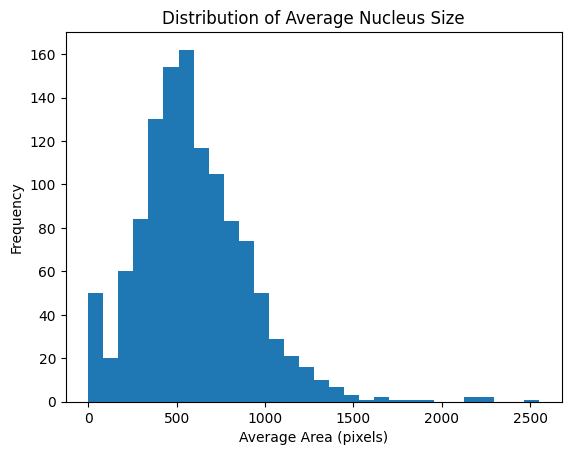

In [ ]:
# Histogram of Raw Nucleus Size;

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["avg_area"], bins=30)
plt.title("Distribution of Average Nucleus Size")
plt.xlabel("Average Area (pixels)")
plt.ylabel("Frequency")
plt.show()

# this took me a second to understand, it basically means that, nucleus having 500pixels as their raw area is highest no as frequency is 160 and "raw area = 2500" is 1;

# skewed left --->  mostly small nuclei
# skewed right ---> many large nuclei
# spread --->       variability

# but as this plotting is done using Raw Area(pixels), this is contains bias towards the Actual Cell/Tissue Image Size/Resolution; so it is better to plot using Normalized Features;

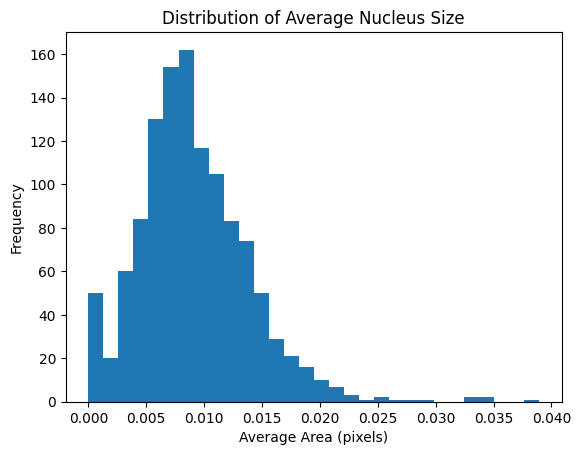

In [ ]:
# Histogram of Normalized Nucleus Size;

plt.figure()
plt.hist(df["avg_norm_area"], bins=30) # now i have plotted using Normalized Average Area of Single Nucleus;
plt.title("Distribution of Average Nucleus Size")
plt.xlabel("Average Area (pixels)")
plt.ylabel("Frequency")
plt.show()

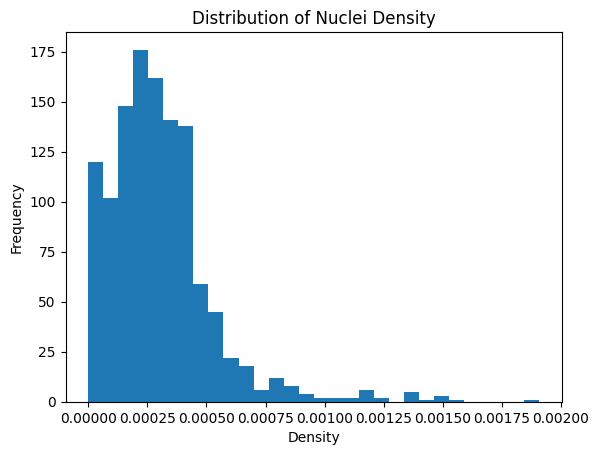

In [5]:
# Histogram of DENSITY;

plt.figure()
plt.hist(df["density"], bins=30)
plt.title("Distribution of Nuclei Density")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

In [7]:
# UPDATING THE ANALYSIS CSV : ADDING COLUMN - 'Variance of nucleus size (per image)'

df["area_variance_proxy"] = df["avg_area"].var()
df["area_variance_proxy"].head()
df.head()

,image_name,nuclei_count,total_area,avg_area,avg_norm_area,density,area_variance_proxy
0,1-100.png,20,10059.041025,502.952051,0.007674,0.000305,100920.396883
1,1-1000.png,0,0.000000,0.000000,0.000000,0.000000,100920.396883
2,1-1009.png,14,10371.360549,740.811468,0.011304,0.000214,100920.396883
3,1-1012.png,11,7308.000390,664.363672,0.010137,0.000168,100920.396883
4,1-1020.png,66,25009.040617,378.924858,0.005782,0.001007,100920.396883


In [ ]:
# df.corr() # ---> It tries to compute correlation between ALL columns but thi 'correlation' operation can only be performed on float/integer value, but my csv file contains a column as "names" which contains string values; error;


df.select_dtypes(include='number').corr() # as this will only find the correlation between number(float/int) columns;

# interpretting the output : 

    # nuclei_count <----> total_area = 0.66 ==> Moderate positive correlation = no. of more nuclei gets more total area; ==> Total nuclear area increases with nuclei count, though not proportionally, indicating variability in nucleus size across images
    
    # total_area <----> avg_area = 0.49     ==> Images with larger nuclei tend to have larger total coverage; ==> Larger nuclei contribute to greater total area
    
    # nuclei_count <----> avg_area = -0.12  ==> If the tissue has more no. of nuclei, then it means that tissue has smaller sized nuclei;
    
    # density <----> avg_area = -0.12       ==> As nuclei become more crowded, their average size slightly decreases.;      ==>A weak inverse relationship between nuclei density and average nucleus size suggests that densely packed regions may exhibit spatial constraints leading to smaller nuclei
    

,nuclei_count,total_area,avg_area,avg_norm_area,density,area_variance_proxy
nuclei_count,1.000000,0.660697,-0.120822,-0.120822,1.000000,NaN
total_area,0.660697,1.000000,0.494489,0.494489,0.660697,NaN
avg_area,-0.120822,0.494489,1.000000,1.000000,-0.120822,NaN
avg_norm_area,-0.120822,0.494489,1.000000,1.000000,-0.120822,NaN
density,1.000000,0.660697,-0.120822,-0.120822,1.000000,NaN
area_variance_proxy,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Scatter Plot

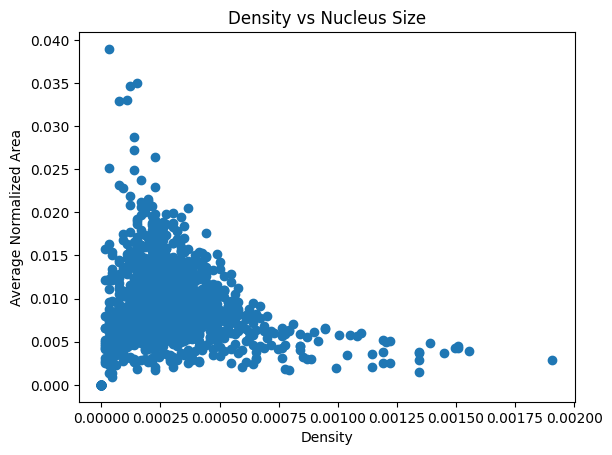

In [ ]:
plt.figure()
plt.scatter(df["density"], df["avg_norm_area"])
plt.xlabel("Density")
plt.ylabel("Average Normalized Area")
plt.title("Density vs Nucleus Size")
plt.show()


# each dot = one image;
# Downward trend : this matches the correlation thing : -0.12
    # low density → large size  
    # high density → small size

In [ ]:
# Extreme cases : 

In [ ]:
df.sort_values("density", ascending=False).head() # ---> images with highest density

,image_name,nuclei_count,total_area,avg_area,avg_norm_area,density,area_variance_proxy
755,2-844.png,125,23658.000573,189.264005,0.002888,0.001907,100920.396883
264,1-2610.png,102,26402.320513,258.846280,0.003950,0.001556,100920.396883
79,1-1486.png,99,29318.480035,296.146263,0.004519,0.001511,100920.396883
736,2-727.png,99,27633.201759,279.123250,0.004259,0.001511,100920.396883
756,2-847.png,98,27460.720272,280.211431,0.004276,0.001495,100920.396883


In [ ]:
df.sort_values("avg_norm_area", ascending=False).head() # ---> images with largest nucleus;

,image_name,nuclei_count,total_area,avg_area,avg_norm_area,density,area_variance_proxy
523,2-1715.png,2,5104.241122,2552.120561,0.038942,0.000031,100920.396883
1016,3-24.png,10,22933.599636,2293.359964,0.034994,0.000153,100920.396883
513,2-1642.png,8,18171.280629,2271.410079,0.034659,0.000122,100920.396883
147,1-1842.png,7,15168.880416,2166.982917,0.033066,0.000107,100920.396883
909,3-1747.png,5,10791.600815,2158.320163,0.032933,0.000076,100920.396883
